# 05 — Timeywimey: Bendalloy Bubbles

The bubble model (`sim/bubbles.py`) is one mechanism and nothing else: a
bubble is a fixed circular region where each body's *local tick* is scaled by
a time factor (> 1 bendalloy, < 1 cadmium). The world computes every body's
local tick each step; integration, healing, feruchemy — everything — runs on
local time. **No other code knows bubbles exist.**

Canon honored, and how:

- **Bubbles are anchored where cast** (they don't follow the caster; only a
  savant can self-anchor). Ours are fixed regions, full stop.
- **A bullet exiting a bubble drops to its outside speed.** In this model that
  must *emerge*: velocity is stored per local second, and a bubble only changes
  experienced time — so there is nothing to reset at the boundary.
- **Boundary deflection** needs extended bodies (a nose and tail in different
  time rates). Our bodies are points; deflection is deliberately absent and
  waits for the two-point rigid bullet experiment.

The bar from notebook 04: Wayne's fast healing must appear without touching a
single line of health or gold code. Otherwise it isn't a sim.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from sim import Body, World, Health, GoldFeruchemy, Poison, SpeedBubble


def run_sampling(world, duration_seconds, sample):
    times, values = [], []
    for _ in range(int(duration_seconds / world.dt_seconds)):
        world.step()
        times.append(world.time_seconds)
        values.append(sample())
    return np.array(times), np.array(values)

## Experiment A — time itself, validated

Two identical balls dropped from 5 m. One falls inside a 5× bendalloy bubble.
Local physics is identical, so the bubbled ball should land in exactly one
fifth the external time.

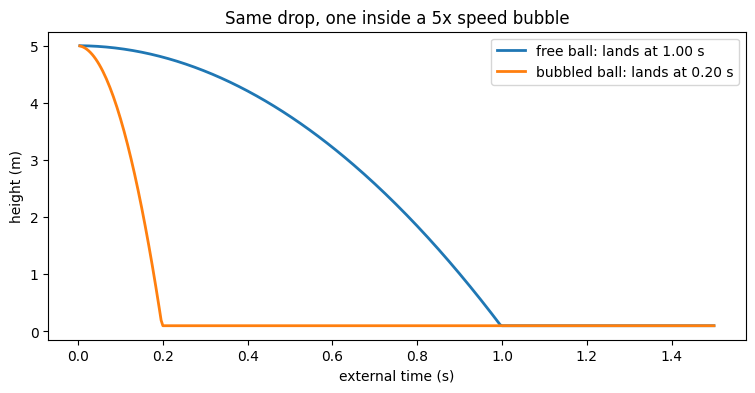

In [2]:
world = World()
free_ball = world.add_body(Body("free ball", 1.0, (0, 5), radius_m=0.1))
fast_ball = world.add_body(Body("bubbled ball", 1.0, (10, 5), radius_m=0.1))
world.add_bubble(SpeedBubble(center=(10, 3), radius_m=3.5, time_factor=5.0))
world.run(1.5)

figure, ax = plt.subplots(figsize=(9, 4))
for name in ["free ball", "bubbled ball"]:
    data = world.history.body(name)
    landing = data["t"][np.argmax(data["on_ground"])]
    ax.plot(data["t"], data["y"], linewidth=2, label=f"{name}: lands at {landing:.2f} s")
ax.set_xlabel("external time (s)")
ax.set_ylabel("height (m)")
ax.set_title("Same drop, one inside a 5x speed bubble")
ax.legend()
plt.show()

## Experiment B — the bullet through the bubble

A ball at 20 m/s crosses a 5 m-radius bubble at altitude. Watch for two things:

1. **Inside, it covers ground at ~100 m/s of external speed** (20 m/s of local
   velocity × 5× time).
2. **It exits at 20 m/s** — the canon "robbed of kinetic energy on exit,"
   emerging for free, because its velocity state never changed; only its
   experienced time did.

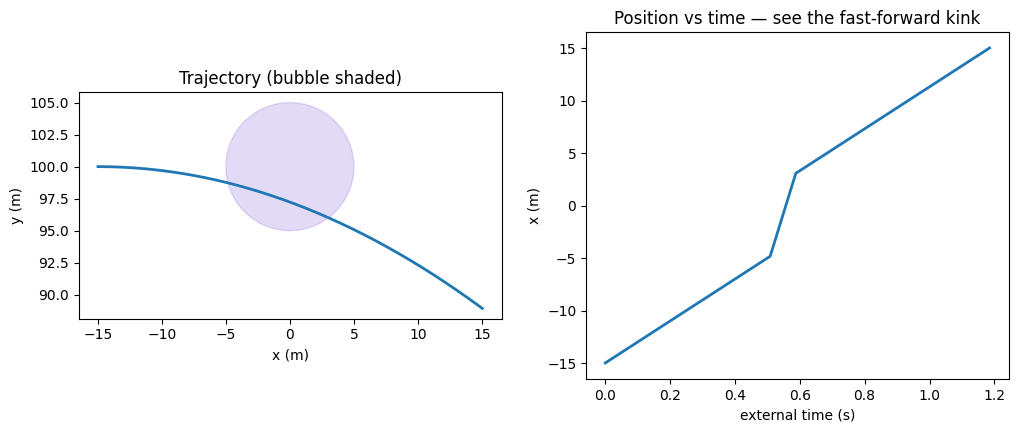

vx before: 20.0 m/s   vx after exit: 20.0 m/s (untouched, no reset code)
CORRECTION (found while writing notebook 07): an earlier version of this
cell claimed the ball 'fell further' inside the bubble. FALSE — the
spatial path is identical with or without the bubble (verified to
millimeters in 07 Experiment B). Bubbles change WHEN, never WHERE.


In [3]:
world = World(dt_seconds=1.0 / 1000.0)
ball = world.add_body(Body("ball", 1.0, (-15, 100), velocity=(20, 0), radius_m=0.1))
bubble = world.add_bubble(SpeedBubble(center=(0, 100), radius_m=5, time_factor=5.0))

while ball.position[0] < 15:
    world.step()

data = world.history.body("ball")
figure, (ax_path, ax_x) = plt.subplots(1, 2, figsize=(12, 4.5))

ax_path.plot(data["x"], data["y"], linewidth=2)
ax_path.add_patch(plt.Circle(bubble.center, bubble.radius_m, color="mediumpurple", alpha=0.25))
ax_path.set_xlabel("x (m)"); ax_path.set_ylabel("y (m)")
ax_path.set_title("Trajectory (bubble shaded)")
ax_path.set_aspect("equal")

ax_x.plot(data["t"], data["x"], linewidth=2)
ax_x.set_xlabel("external time (s)"); ax_x.set_ylabel("x (m)")
ax_x.set_title("Position vs time — see the fast-forward kink")
plt.show()

print(f"vx before: 20.0 m/s   vx after exit: {ball.velocity[0]:.1f} m/s (untouched, no reset code)")
print("CORRECTION (found while writing notebook 07): an earlier version of this")
print("cell claimed the ball 'fell further' inside the bubble. FALSE — the")
print("spatial path is identical with or without the bubble (verified to")
print("millimeters in 07 Experiment B). Bubbles change WHEN, never WHERE.")

## Experiment C — THE test: Wayne in the bubble

Two identical Waynes: 60 damage, tapping gold at 10 HP/s. One stands inside a
5× bubble. The health and gold code is byte-for-byte the notebook-04 code.
If the architecture is honest, the bubbled Wayne heals five times faster in
external time — and if we had to special-case anything, the sim fails its own
founding rule.

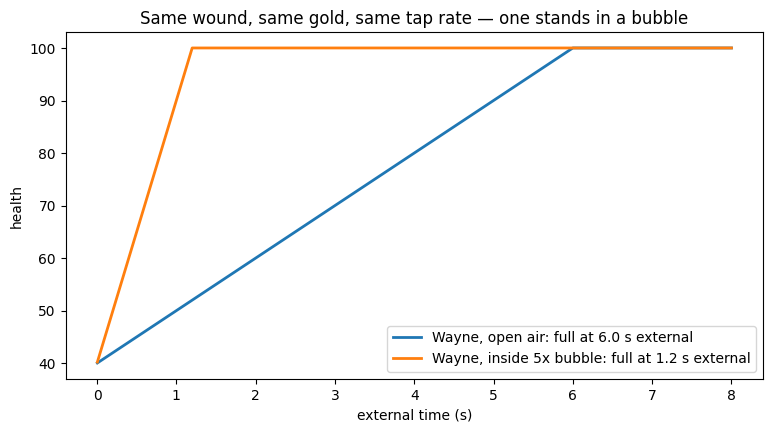

In [4]:
figure, ax = plt.subplots(figsize=(9, 4.5))

for label, with_bubble in [("Wayne, open air", False), ("Wayne, inside 5x bubble", True)]:
    world = World()
    wayne = world.add_body(Body("wayne", 70, (0, 0.3)))
    health = world.add_power(Health(wayne, max_health=100, natural_regen_per_second=0))
    goldmind = world.add_power(GoldFeruchemy(health, initial_reserve_health_points=100))
    if with_bubble:
        world.add_bubble(SpeedBubble(center=(0, 0.3), radius_m=2, time_factor=5.0))
    health.damage(60)
    goldmind.tap(10)
    times, hp = run_sampling(world, 8.0, lambda: health.current)
    full_at = times[np.argmax(hp >= 99.9)]
    ax.plot(times, hp, linewidth=2, label=f"{label}: full at {full_at:.1f} s external")

ax.set_xlabel("external time (s)")
ax.set_ylabel("health")
ax.set_title("Same wound, same gold, same tap rate — one stands in a bubble")
ax.legend(loc="lower right")
plt.show()

## Experiment D — what the bubble can't save you from

Poison lives in Wayne's bloodstream, so it runs on his local clock too. Two
unhealing Waynes take the same 5 HP/s poison; one hides in a bubble. The
bubble doesn't dilute the venom — it fast-forwards the dying.

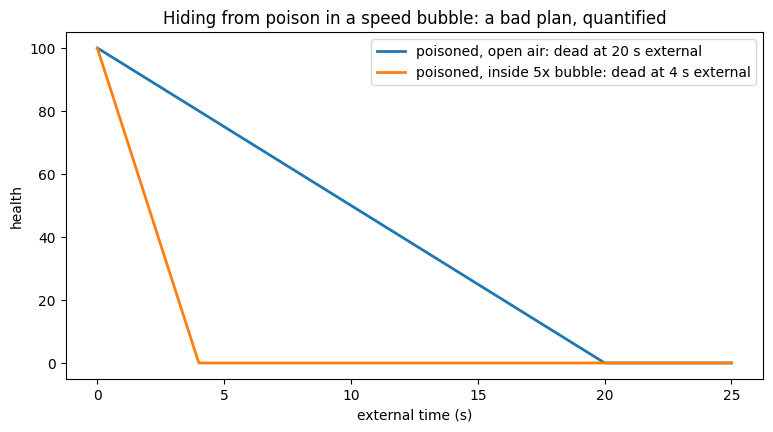

In [5]:
figure, ax = plt.subplots(figsize=(9, 4.5))

for label, with_bubble in [("poisoned, open air", False), ("poisoned, inside 5x bubble", True)]:
    world = World()
    wayne = world.add_body(Body("wayne", 70, (0, 0.3)))
    health = world.add_power(Health(wayne, max_health=100, natural_regen_per_second=0))
    world.add_power(Poison(health, damage_per_second=5))
    if with_bubble:
        world.add_bubble(SpeedBubble(center=(0, 0.3), radius_m=2, time_factor=5.0))
    times, hp = run_sampling(world, 25.0, lambda: health.current)
    death = times[np.argmax(hp <= 0)]
    ax.plot(times, hp, linewidth=2, label=f"{label}: dead at {death:.0f} s external")

ax.set_xlabel("external time (s)")
ax.set_ylabel("health")
ax.set_title("Hiding from poison in a speed bubble: a bad plan, quantified")
ax.legend(loc="upper right")
plt.show()

## Findings

1. **The time machinery is exact**: bubbled ball lands in precisely 1/5 the
   external time; the crossing ball does ~100 m/s of external ground speed
   inside and exits at its untouched 20 m/s. The canon exit-speed rule
   *emerged* — there is no boundary code to write, which is the strongest
   possible sign the time model is the right shape.
2. **Wayne's signature trick is real and uncoded**: normal-rate healing inside
   compressed time = fast healing outside. Health code from notebook 04,
   untouched, byte for byte. The founding rule held.
3. **Bubbles accelerate everything in them, including your problems**: poison
   kills five times sooner inside. Bendalloy buys time against the *outside*
   world only. Tactical depth, free of charge.
4. **Next (06): Miles.** Gold allomancy + gold feruchemy = Compounding — the
   rule-breaker. Burning a goldmind returns the stored attribute roughly
   tenfold (canon-cited, tunable), which should make him functionally
   unkillable right up until the metal runs out. The experiment: find his
   breaking point.